In [2]:
# Fraud Label Creation for Medicare Claims
# Create target variable using statistical and rule-based methods

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("="*70)
print("FRAUD LABEL CREATION")
print("="*70)


FRAUD LABEL CREATION


In [3]:
# =============================================================================
# PART 1: LOAD FEATURED DATA
# =============================================================================

print("\n Loading featured datasets...")
PROJECT_ROOT = Path().resolve().parents[1]
data_path = PROJECT_ROOT / "data" / "processed" 
inpatient= pd.read_csv(data_path / 'Inpatient_featured.csv')
outpatient=pd.read_csv(data_path / 'Outpatient_featured.csv')

print(f" Inpatient: {len(inpatient):,} claims")
print(f" Outpatient: {len(outpatient):,} claims")


 Loading featured datasets...
 Inpatient: 66,773 claims
 Outpatient: 790,790 claims


In [4]:

# =============================================================================
# PART 2: METHOD 1 - STATISTICAL OUTLIERS
# =============================================================================

print("\n" + "="*70)
print("METHOD 1: STATISTICAL OUTLIER DETECTION")
print("="*70)

def flag_statistical_outliers(df, z_threshold=3):
    """Flag claims as outliers based on multiple statistical criteria"""
    
    flags = pd.DataFrame(index=df.index)
    
    # 1. Payment amount outliers (z-score > 3)
    flags['flag_payment_outlier'] = (np.abs(df['payment_zscore']) > z_threshold).astype(int)
    
    # 2. Extreme payment percentile (top 1%)
    flags['flag_extreme_payment'] = (df['payment_percentile'] > 0.99).astype(int)
    
    # 3. High provider volume
    flags['flag_high_provider_volume'] = (
        df['provider_volume_percentile'] > 0.95
    ).astype(int)
    
    # 4. High claims per day (rapid fire billing)
    flags['flag_rapid_billing'] = (
        df['bene_claims_per_day'] > df['bene_claims_per_day'].quantile(0.99)
    ).astype(int)
    
    # 5. Excessive provider shopping
    flags['flag_provider_shopping'] = (
        df['bene_unique_providers'] > df['bene_unique_providers'].quantile(0.95)
    ).astype(int)
    
    # 6. Payment much higher than provider average
    flags['flag_payment_above_provider_norm'] = (
        df['payment_deviation_from_provider_avg'] > 
        df['payment_deviation_from_provider_avg'].quantile(0.95)
    ).astype(int)
    
    # 7. High payment variance (provider inconsistency)
    flags['flag_provider_high_variance'] = (
        df['provider_payment_cv'] > df['provider_payment_cv'].quantile(0.90)
    ).astype(int)
    
    return flags

print("\n Detecting statistical outliers...")
ip_stat_flags = flag_statistical_outliers(inpatient)
op_stat_flags = flag_statistical_outliers(outpatient)

# Count flags per claim
ip_stat_flags['stat_flag_count'] = ip_stat_flags.sum(axis=1)
op_stat_flags['stat_flag_count'] = op_stat_flags.sum(axis=1)

print("\n Statistical Outlier Results (Inpatient):")
for col in ip_stat_flags.columns[:-1]:
    count = ip_stat_flags[col].sum()
    pct = count / len(inpatient) * 100
    print(f"  {col:40} {count:6,} ({pct:4.1f}%)")

print(f"\n  Claims with 3+ flags: {(ip_stat_flags['stat_flag_count'] >= 3).sum():,}")
print(f"  Claims with 5+ flags: {(ip_stat_flags['stat_flag_count'] >= 5).sum():,}")


METHOD 1: STATISTICAL OUTLIER DETECTION

 Detecting statistical outliers...

 Statistical Outlier Results (Inpatient):
  flag_payment_outlier                      1,738 ( 2.6%)
  flag_extreme_payment                        679 ( 1.0%)
  flag_high_provider_volume                15,164 (22.7%)
  flag_rapid_billing                           21 ( 0.0%)
  flag_provider_shopping                    2,677 ( 4.0%)
  flag_payment_above_provider_norm          3,339 ( 5.0%)
  flag_provider_high_variance               6,669 (10.0%)

  Claims with 3+ flags: 1,298
  Claims with 5+ flags: 61


### METHOD 1 – STATISTICAL OUTLIER DETECTION

---

#### What are we doing?

* Identifying **suspicious healthcare insurance claims** using statistical rules
* Flagging claims that **deviate significantly from normal behavior**
* This step **does NOT confirm fraud**, it only highlights risk

---

#### Why are we doing this?

* Healthcare fraud labels are usually **not available**
* Fraud cases are **rare and hidden in extreme patterns**
* Statistical outliers are often **high-risk claims**
* This approach works well as an **unsupervised fraud screening method**

---

#### What does the function do?

* The function `flag_statistical_outliers()` creates **multiple fraud risk flags**
* Each flag represents **one abnormal statistical behavior**
* Output is a DataFrame with **binary indicators (0/1)** per claim

---

### Fraud flags explained

##### 1. Payment amount outlier (Z-score)

* Checks if the claim payment is **extremely high or low**
* Uses Z-score threshold (default = 3)
* Possible fraud signals:

  * Upcoding
  * Overbilling
  * Phantom services

---

##### 2. Extreme payment percentile

* Flags claims in the **top 1% of payment amounts**
* Extremely costly claims require **additional scrutiny**

---

##### 3. High provider claim volume

* Identifies providers submitting **unusually high numbers of claims**
* Possible fraud signals:

  * Billing factories
  * Kickback networks

---

##### 4. Rapid-fire billing

* Flags beneficiaries with **too many claims in a single day**
* Possible fraud signals:

  * Impossible service frequency
  * Card sharing

---

##### 5. Excessive provider shopping

* Identifies beneficiaries visiting **too many different providers**
* Possible fraud signals:

  * Doctor shopping
  * Claim splitting

---

##### 6. Payment above provider normal behavior

* Checks if a claim payment is **much higher than the provider’s own average**
* Possible fraud signals:

  * One-off inflated claims

---

##### 7. High provider payment variance

* Identifies providers with **inconsistent billing patterns**
* Possible fraud signals:

  * Manipulation of billing rules

---

#### How is overall risk measured?

* All flags are summed per claim
* `stat_flag_count` = number of triggered fraud signals

---

#### How to interpret the results

* 0–1 flags  → Low risk
* 2 flags    → Medium risk
* 3+ flags   → High risk (SIU review recommended)
* 5+ flags   → Very high risk (urgent investigation)

---

#### Key takeaway

* This method provides an **explainable, business-aligned fraud screening layer**
* It helps prioritize claims **before manual review or ML modeling**
* This approach closely matches **real-world insurance fraud detection systems**


In [6]:

# =============================================================================
# PART 3: METHOD 2 - ISOLATION FOREST (ANOMALY DETECTION)
# =============================================================================

print("\n" + "="*70)
print("METHOD 2: ISOLATION FOREST ANOMALY DETECTION")
print("="*70)

def detect_anomalies_isolation_forest(df, contamination=0.05):
    """Use Isolation Forest to detect anomalous claims"""
    
    # Select numerical features for anomaly detection
    feature_cols = [
        'CLM_PMT_AMT',
        'provider_claim_count',
        'provider_avg_payment',
        'provider_payment_cv',
        'bene_claim_count',
        'bene_unique_providers',
        'bene_claims_per_day',
        'chronic_condition_count',
        'diagnosis_code_count',
        'procedure_code_count',
        'payment_zscore'
    ]
    
    X = df[feature_cols].copy()

    #  FIX: Replace inf and -inf with NaN
    X.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Fill missing values with median
    X = X.fillna(X.median())
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Train Isolation Forest
    iso_forest = IsolationForest(
        contamination=contamination,
        random_state=42,
        n_estimators=100,
        max_samples='auto'
    )
    
    # Predict (-1 = anomaly, 1 = normal)
    predictions = iso_forest.fit_predict(X_scaled)
    
    # Get anomaly scores (lower = more anomalous)
    anomaly_scores = iso_forest.score_samples(X_scaled)
    
    return (predictions == -1).astype(int), anomaly_scores

print("\n Training Isolation Forest on inpatient claims...")
ip_anomaly_flag, ip_anomaly_scores = detect_anomalies_isolation_forest(inpatient, contamination=0.05)

print(" Training Isolation Forest on outpatient claims...")
op_anomaly_flag, op_anomaly_scores = detect_anomalies_isolation_forest(outpatient, contamination=0.05)

print(f"\n Isolation Forest Results:")
print(f"  Inpatient anomalies: {ip_anomaly_flag.sum():,} ({ip_anomaly_flag.mean()*100:.1f}%)")
print(f"  Outpatient anomalies: {op_anomaly_flag.sum():,} ({op_anomaly_flag.mean()*100:.1f}%)")


METHOD 2: ISOLATION FOREST ANOMALY DETECTION

 Training Isolation Forest on inpatient claims...
 Training Isolation Forest on outpatient claims...

 Isolation Forest Results:
  Inpatient anomalies: 3,339 (5.0%)
  Outpatient anomalies: 39,540 (5.0%)


#### METHOD 2 – ISOLATION FOREST (ANOMALY DETECTION)

---

##### What is this method?

* This method uses **Isolation Forest**, an **unsupervised machine learning algorithm**
* It is designed to **detect anomalous (abnormal) healthcare insurance claims**
* No fraud labels are required
* Claims that behave very differently from normal patterns are flagged

---

##### Why use Isolation Forest for fraud detection?

* Healthcare fraud data is mostly **unlabeled**
* Fraud cases are **rare**
* Fraud patterns are often **complex and non-linear**
* Isolation Forest is effective at identifying **rare and extreme behaviors**

---

##### What does the function do?

* The function `detect_anomalies_isolation_forest()`:

  * Selects important numerical claim features
  * Scales the data
  * Trains an Isolation Forest model
  * Flags anomalous claims
  * Produces an anomaly risk score

---

##### Features used for anomaly detection

The model uses the following numerical features to learn claim behavior:

* `CLM_PMT_AMT` – Claim payment amount
* `provider_claim_count` – Total claims submitted by provider
* `provider_avg_payment` – Average payment amount for the provider
* `provider_payment_cv` – Variability in provider billing behavior
* `bene_claim_count` – Total claims for the beneficiary
* `bene_unique_providers` – Number of providers visited by the beneficiary
* `bene_claims_per_day` – Claims submitted per day by the beneficiary
* `chronic_condition_count` – Number of chronic conditions
* `diagnosis_code_count` – Number of diagnosis codes on the claim
* `procedure_code_count` – Number of procedure codes on the claim
* `payment_zscore` – Statistical extremeness of payment amount

---

##### Data preprocessing steps

###### Handling missing values

* Missing values are replaced using the **median** of each feature
* This prevents model failure and reduces outlier bias

###### Feature scaling

* All features are standardized using `StandardScaler`
* This ensures features with large values (e.g., payment amounts) do not dominate the model

---

##### Isolation Forest model training

* The model assumes approximately **5% of claims are anomalous** (`contamination = 0.05`)
* Multiple decision trees are built using random subsets of data
* Anomalous claims are isolated faster than normal claims

---

##### Model outputs

###### Anomaly flag

* `1` → Anomalous (suspicious) claim
* `0` → Normal claim

###### Anomaly score

* Continuous risk score per claim
* Lower score = more anomalous
* Used for ranking claims by risk

---

##### Applying the model

* The same function is applied separately to:

  * Inpatient claims
  * Outpatient claims
* This is done because billing patterns differ between claim types

---

##### How to interpret the results

* Flagged claims represent the **most unusual behavior patterns**
* These claims are prioritized for:

  * SIU (Special Investigation Unit) review
  * Manual audit
  * Further fraud analysis

---

##### How this fits in the fraud detection pipeline

* Method 1 (Statistical Rules) → Explainable red flags
* Method 2 (Isolation Forest) → ML-based anomaly detection
* Claims flagged by both methods are considered **high-risk**

---

##### Key takeaway

* Isolation Forest provides a powerful, label-free way to identify suspicious healthcare claims
* It complements rule-based methods and closely mirrors real-world insurance fraud detection systems


In [7]:

# =============================================================================
# PART 4: METHOD 3 - RULE-BASED FRAUD FLAGS
# =============================================================================

print("\n" + "="*70)
print("METHOD 3: RULE-BASED FRAUD INDICATORS")
print("="*70)

def flag_rule_based_fraud(df, claim_type='IP'):
    """Apply domain-specific rules for fraud detection"""
    
    flags = pd.DataFrame(index=df.index)
    
    # Rule 1: Zero payment claims (potential kickback schemes)
    flags['rule_zero_payment'] = (df['CLM_PMT_AMT'] == 0).astype(int)
    
    # Rule 2: Very low cost per condition (unbundling)
    if claim_type == 'IP':
        flags['rule_low_cost_per_condition'] = (
            (df['cost_per_condition'] < df['cost_per_condition'].quantile(0.05)) &
            (df['chronic_condition_count'] > 0)
        ).astype(int)
    
    # Rule 3: Excessive diagnosis codes (upcoding)
    flags['rule_excessive_diagnoses'] = (
        df['diagnosis_code_count'] > df['diagnosis_code_count'].quantile(0.95)
    ).astype(int)
    
    # Rule 4: Excessive procedure codes
    flags['rule_excessive_procedures'] = (
        df['procedure_code_count'] > df['procedure_code_count'].quantile(0.95)
    ).astype(int)
    
    # Rule 5: Weekend billing (unusual pattern)
    flags['rule_weekend_billing'] = df['claim_is_weekend']
    
    # Rule 6: Very short length of stay for high payment (inpatient)
    if claim_type == 'IP':
        flags['rule_short_stay_high_payment'] = (
            (df['length_of_stay'] <= 1) &
            (df['CLM_PMT_AMT'] > df['CLM_PMT_AMT'].median())
        ).astype(int)
    
    # Rule 7: Payment per day outlier (inpatient)
    if claim_type == 'IP':
        flags['rule_high_payment_per_day'] = (
            df['payment_per_day'] > df['payment_per_day'].quantile(0.95)
        ).astype(int)
    
    # Rule 8: Beneficiary with unusually high total costs
    flags['rule_high_bene_total'] = (
        df['bene_total_payment'] > df['bene_total_payment'].quantile(0.98)
    ).astype(int)
    
    return flags

print("\n Applying rule-based flags...")
ip_rule_flags = flag_rule_based_fraud(inpatient, 'IP')
op_rule_flags = flag_rule_based_fraud(outpatient, 'OP')

# Count rules triggered
ip_rule_flags['rule_flag_count'] = ip_rule_flags.sum(axis=1)
op_rule_flags['rule_flag_count'] = op_rule_flags.sum(axis=1)

print("\n Rule-Based Results (Inpatient):")
for col in ip_rule_flags.columns[:-1]:
    count = ip_rule_flags[col].sum()
    pct = count / len(inpatient) * 100
    print(f"  {col:40} {count:6,} ({pct:4.1f}%)")



METHOD 3: RULE-BASED FRAUD INDICATORS

 Applying rule-based flags...

 Rule-Based Results (Inpatient):
  rule_zero_payment                         2,160 ( 3.2%)
  rule_low_cost_per_condition               3,021 ( 4.5%)
  rule_excessive_diagnoses                      0 ( 0.0%)
  rule_excessive_procedures                 3,233 ( 4.8%)
  rule_weekend_billing                     19,203 (28.8%)
  rule_short_stay_high_payment                322 ( 0.5%)
  rule_high_payment_per_day                 2,974 ( 4.5%)
  rule_high_bene_total                      1,334 ( 2.0%)


### METHOD 3 – RULE-BASED FRAUD FLAGS

#### Objective
- Apply predefined healthcare fraud rules
- Identify suspicious insurance claims
- Generate explainable fraud indicators for SIU investigation

#### Why Rule-Based Fraud Detection
- Detects known fraud and abuse patterns
- Fully explainable and audit-friendly
- Works without labeled fraud data
- Widely used by Special Investigation Units (SIU)
- Complements statistical and ML-based methods

##### Function Overview

    def flag_rule_based_fraud(df, claim_type='IP'):

- df: claims dataset
- claim_type:
  - IP: inpatient claims
  - OP: outpatient claims
- Output:
  - 1: rule triggered (suspicious)
  - 0: normal claim

##### Rule Definitions

##### Rule 1: Zero Payment Claims
- Condition:
  - CLM_PMT_AMT == 0
- Fraud Pattern:
  - Fake or placeholder claims
  - Kickback schemes
  - Artificial claim volume inflation

##### Rule 2: Very Low Cost per Condition (IP Only)
- Condition:
  - cost_per_condition < 5th percentile
  - chronic_condition_count > 0
- Fraud Pattern:
  - Unbundling of services
  - Misrepresentation of treatment cost

##### Rule 3: Excessive Diagnosis Codes
- Condition:
  - diagnosis_code_count > 95th percentile
- Fraud Pattern:
  - Upcoding to justify higher reimbursement

##### Rule 4: Excessive Procedure Codes
- Condition:
  - procedure_code_count > 95th percentile
- Fraud Pattern:
  - Billing unnecessary or fictitious procedures

##### Rule 5: Weekend Billing
- Condition:
  - claim_is_weekend == True
- Fraud Pattern:
  - Unusual service timing
  - Automated or bulk claim submissions

##### Rule 6: Short Length of Stay with High Payment (IP Only)
- Condition:
  - length_of_stay <= 1
  - CLM_PMT_AMT > median
- Fraud Pattern:
  - Ghost admissions
  - Inflated billing

##### Rule 7: High Payment per Day (IP Only)
- Condition:
  - payment_per_day > 95th percentile
- Fraud Pattern:
  - ICU or room charge inflation

##### Rule 8: Beneficiary with Extremely High Total Cost
- Condition:
  - bene_total_payment > 98th percentile
- Fraud Pattern:
  - Provider–beneficiary collusion
  - Repeated or recycled claims

#### Rule Aggregation
- rule_flag_count = sum of all triggered rules per claim

#### Risk Interpretation
- 0–1 flags: low risk
- 2–3 flags: medium risk
- 4+ flags: high risk (SIU review)

#### Role in Fraud Framework
- Provides transparent fraud indicators
- Supports investigation and audits
- Enhances trust in ML-based models

In [8]:

# =============================================================================
# PART 5: COMBINE METHODS INTO FRAUD SCORE
# =============================================================================

print("\n" + "="*70)
print("CREATING COMPOSITE FRAUD SCORE")
print("="*70)

def create_fraud_score(stat_flags, anomaly_flag, anomaly_scores, rule_flags):
    """Combine multiple methods into single fraud score"""
    
    # Weighted scoring
    score = pd.Series(0.0, index=stat_flags.index)
    
    # Statistical flags (weight: 0.3)
    score += stat_flags['stat_flag_count'] * 0.05
    
    # Isolation Forest (weight: 0.4)
    score += anomaly_flag * 0.4
    
    # Normalize anomaly scores to 0-1 and add (weight: 0.1)
    norm_scores = (anomaly_scores - anomaly_scores.min()) / (anomaly_scores.max() - anomaly_scores.min())
    score += (1 - norm_scores) * 0.1  # Lower score = more anomalous
    
    # Rule-based flags (weight: 0.2)
    score += rule_flags['rule_flag_count'] * 0.04
    
    # Normalize to 0-1
    score = (score - score.min()) / (score.max() - score.min())
    
    return score

print("\n Calculating composite fraud scores...")
inpatient['fraud_score'] = create_fraud_score(
    ip_stat_flags, ip_anomaly_flag, ip_anomaly_scores, ip_rule_flags
)

outpatient['fraud_score'] = create_fraud_score(
    op_stat_flags, op_anomaly_flag, op_anomaly_scores, op_rule_flags
)

# Create binary fraud labels (multiple thresholds)
for threshold in [0.6, 0.7, 0.8, 0.9]:
    inpatient[f'is_fraud_{int(threshold*100)}'] = (
        inpatient['fraud_score'] >= threshold
    ).astype(int)
    outpatient[f'is_fraud_{int(threshold*100)}'] = (
        outpatient['fraud_score'] >= threshold
    ).astype(int)

print("\n Fraud Score Distribution:")
print(inpatient['fraud_score'].describe())

print("\n Fraud Labels at Different Thresholds (Inpatient):")
for threshold in [60, 70, 80, 90]:
    col = f'is_fraud_{threshold}'
    count = inpatient[col].sum()
    pct = count / len(inpatient) * 100
    print(f"  Threshold {threshold/100:.1f}: {count:6,} claims ({pct:4.1f}%)")



CREATING COMPOSITE FRAUD SCORE

 Calculating composite fraud scores...

 Fraud Score Distribution:
count    66773.000000
mean         0.093703
std          0.141641
min          0.000000
25%          0.018307
50%          0.060028
75%          0.101468
max          1.000000
Name: fraud_score, dtype: float64

 Fraud Labels at Different Thresholds (Inpatient):
  Threshold 0.6:  2,447 claims ( 3.7%)
  Threshold 0.7:  1,203 claims ( 1.8%)
  Threshold 0.8:    229 claims ( 0.3%)
  Threshold 0.9:     16 claims ( 0.0%)


### COMBINING METHODS INTO A COMPOSITE FRAUD SCORE

#### Objective
- Combine statistical, ML-based, and rule-based fraud signals
- Generate a single fraud risk score per claim
- Enable claim prioritization for SIU investigation

---

#### Why a Composite Fraud Score
- No single method is sufficient to detect fraud
- Different methods capture different fraud behaviors
- SIU teams require one interpretable risk score
- Supports threshold-based alerting and investigation workflows

---

#### Function Overview

    def create_fraud_score(stat_flags, anomaly_flag, anomaly_scores, rule_flags):

##### Inputs
- stat_flags: statistical outlier results
- anomaly_flag: Isolation Forest anomaly indicator (0 or 1)
- anomaly_scores: Isolation Forest anomaly scores
- rule_flags: rule-based fraud indicators

##### Output
- Normalized fraud score between 0 and 1

---

#### Fraud Score Construction Logic

##### Statistical Outlier Contribution
- Uses count of statistical red flags
- Weight: ~0.3
- Captures extreme or abnormal claim behavior

---

##### Isolation Forest Contribution
- Binary anomaly flag
- Weight: 0.4
- Strong signal for unusual claims

---

##### Anomaly Score Normalization
- Normalizes anomaly scores to range 0–1
- Inverts score so higher risk increases fraud score
- Weight: 0.1
- Adds granularity beyond binary detection

---

##### Rule-Based Fraud Contribution
- Uses count of triggered fraud rules
- Weight: ~0.2
- Encodes known healthcare fraud patterns

---

#### Final Normalization
- Fraud score scaled to 0–1
- Ensures comparability across claims
- Enables consistent thresholding

---

#### Fraud Label Thresholds
- Multiple thresholds used to support flexible SIU workflows
- Higher threshold = stricter fraud definition

| Threshold | Interpretation |
|---------|---------------|
| 0.60 | Broad screening |
| 0.70 | Standard SIU review |
| 0.80 | High-risk claims |
| 0.90 | Critical priority claims |

---

#### Business Interpretation
- Fraud score represents risk, not confirmed fraud
- Used to rank and prioritize claims
- Reduces false positives and improves investigation efficiency

---

#### Role in Fraud Detection Framework
- Integrates explainable rules and ML intelligence
- Aligns with real-world healthcare insurance practices
- Enables scalable and auditable fraud detection



VISUALIZING FRAUD PATTERNS


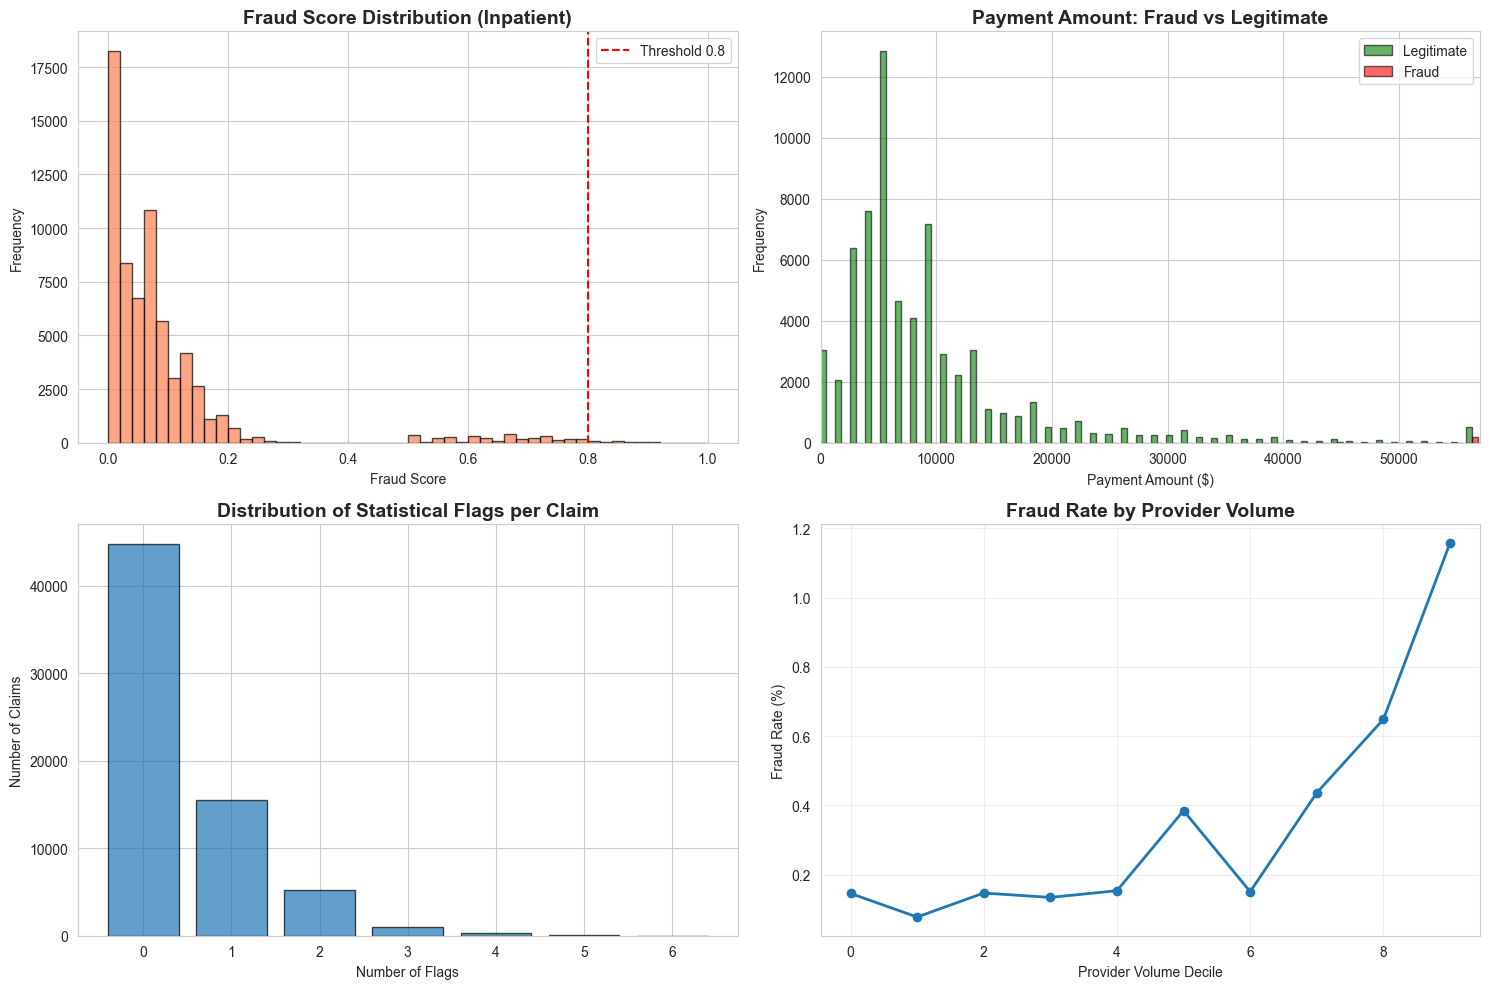

In [9]:

# =============================================================================
# PART 6: VISUALIZATIONS
# =============================================================================

print("\n" + "="*70)
print("VISUALIZING FRAUD PATTERNS")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Fraud score distribution
axes[0, 0].hist(inpatient['fraud_score'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0, 0].axvline(0.8, color='red', linestyle='--', label='Threshold 0.8')
axes[0, 0].set_title('Fraud Score Distribution (Inpatient)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Fraud Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# Payment amount: fraud vs legitimate
fraud_payments = inpatient[inpatient['is_fraud_80'] == 1]['CLM_PMT_AMT']
legit_payments = inpatient[inpatient['is_fraud_80'] == 0]['CLM_PMT_AMT']

axes[0, 1].hist([legit_payments, fraud_payments], bins=50, label=['Legitimate', 'Fraud'],
                color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[0, 1].set_title('Payment Amount: Fraud vs Legitimate', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Payment Amount ($)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].set_xlim(0, fraud_payments.quantile(0.99))

# Statistical flags distribution
flag_counts = ip_stat_flags['stat_flag_count'].value_counts().sort_index()
axes[1, 0].bar(flag_counts.index, flag_counts.values, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribution of Statistical Flags per Claim', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Number of Flags')
axes[1, 0].set_ylabel('Number of Claims')

# Fraud rate by provider volume percentile
bins = pd.qcut(inpatient['provider_volume_percentile'], q=10, duplicates='drop')
fraud_by_volume = inpatient.groupby(bins)['is_fraud_80'].mean() * 100

axes[1, 1].plot(range(len(fraud_by_volume)), fraud_by_volume.values, marker='o', linewidth=2)
axes[1, 1].set_title('Fraud Rate by Provider Volume', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Provider Volume Decile')
axes[1, 1].set_ylabel('Fraud Rate (%)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [10]:

# =============================================================================
# PART 7: SAVE LABELED DATASETS
# =============================================================================

print("\n" + "="*70)
print("SAVING LABELED DATASETS")
print("="*70)

# Add all flags to datasets
inpatient_final = pd.concat([
    inpatient,
    ip_stat_flags,
    pd.Series(ip_anomaly_flag, name='isolation_forest_anomaly', index=inpatient.index),
    pd.Series(ip_anomaly_scores, name='anomaly_score', index=inpatient.index),
    ip_rule_flags
], axis=1)

outpatient_final = pd.concat([
    outpatient,
    op_stat_flags,
    pd.Series(op_anomaly_flag, name='isolation_forest_anomaly', index=outpatient.index),
    pd.Series(op_anomaly_scores, name='anomaly_score', index=outpatient.index),
    op_rule_flags
], axis=1)

# Save
inpatient_final.to_csv(PROJECT_ROOT / "data" / "processed" /'inpatient_labeled.csv', index=False)
outpatient_final.to_csv(PROJECT_ROOT / "data" / "processed" /'outpatient_labeled.csv', index=False)

print(f"\n Saved labeled datasets:")
print(f"  - inpatient_labeled.csv ({len(inpatient_final):,} claims, {inpatient_final.shape[1]} columns)")
print(f"  - outpatient_labeled.csv ({len(outpatient_final):,} claims, {outpatient_final.shape[1]} columns)")



SAVING LABELED DATASETS

 Saved labeled datasets:
  - inpatient_labeled.csv (66,773 claims, 153 columns)
  - outpatient_labeled.csv (790,790 claims, 141 columns)


In [11]:

# =============================================================================
# PART 8: SUMMARY STATISTICS
# =============================================================================

print("\n" + "="*70)
print("FRAUD DETECTION SUMMARY")
print("="*70)

print(f"""
  INPATIENT FRAUD STATISTICS:
  Total claims: {len(inpatient):,}
  
  Fraud labels (threshold 0.8):
    • Flagged as fraud: {inpatient['is_fraud_80'].sum():,} ({inpatient['is_fraud_80'].mean()*100:.2f}%)
    • Legitimate claims: {(1-inpatient['is_fraud_80']).sum():,} ({(1-inpatient['is_fraud_80']).mean()*100:.2f}%)
  
  Average fraud score:
    • Fraud claims: {inpatient[inpatient['is_fraud_80']==1]['fraud_score'].mean():.3f}
    • Legitimate claims: {inpatient[inpatient['is_fraud_80']==0]['fraud_score'].mean():.3f}
  
  Payment comparison:
    • Average fraud claim: ${inpatient[inpatient['is_fraud_80']==1]['CLM_PMT_AMT'].mean():,.2f}
    • Average legitimate claim: ${inpatient[inpatient['is_fraud_80']==0]['CLM_PMT_AMT'].mean():,.2f}
    • Fraud premium: {(inpatient[inpatient['is_fraud_80']==1]['CLM_PMT_AMT'].mean() / inpatient[inpatient['is_fraud_80']==0]['CLM_PMT_AMT'].mean() - 1)*100:.1f}% higher

  NEXT STEPS:
  1. Build baseline classification model (Logistic Regression)
  2. Train advanced models (XGBoost, Random Forest)
  3. Evaluate with appropriate metrics (Precision, Recall, F1)
  4. Optimize decision threshold for business impact
  5. Deploy model with explainability (SHAP values)
""")

print("="*70)
print(" FRAUD LABEL CREATION COMPLETE")
print("="*70)


FRAUD DETECTION SUMMARY

  INPATIENT FRAUD STATISTICS:
  Total claims: 66,773
  
  Fraud labels (threshold 0.8):
    • Flagged as fraud: 229 (0.34%)
    • Legitimate claims: 66,544 (99.66%)
  
  Average fraud score:
    • Fraud claims: 0.843
    • Legitimate claims: 0.091
  
  Payment comparison:
    • Average fraud claim: $53,746.72
    • Average legitimate claim: $9,421.62
    • Fraud premium: 470.5% higher

  NEXT STEPS:
  1. Build baseline classification model (Logistic Regression)
  2. Train advanced models (XGBoost, Random Forest)
  3. Evaluate with appropriate metrics (Precision, Recall, F1)
  4. Optimize decision threshold for business impact
  5. Deploy model with explainability (SHAP values)

 FRAUD LABEL CREATION COMPLETE
